# Four-Layer Thin Film Model: Vacuum/MoOCl₂/SiO₂/Si

**Associated manuscript:** *Spatiotemporal Visualization of Long-Range Anisotropic Plasmon Polaritons in Hyperbolic MoOCl₂*

This notebook implements the four-layer transfer matrix model for the experimental sample geometry: vacuum (medium 1) / MoOCl₂ (medium 2, thickness *d₁*) / SiO₂ (medium 3, thickness *d₂*) / Si(100) (medium 4). It reproduces:

- **Figure 3A** (Main text): Dispersion Im(r_p) and experimental data comparison
- **Figures 3B–E** (Main text): Electric field and Poynting vector distributions for LRAPP and SRAPP modes
- **Figure S3** (Supplementary Information): Line cuts and dispersion comparison
- **Figure S5** (Supplementary Information): Charge density distributions
- **Figure S9** (Supplementary Information): Group and phase velocity comparison

## Physical background

The reflection coefficient for a four-layer stack is computed via the transfer matrix method. The poles of r_p yield the dispersion of guided plasmon polariton modes. For a thin MoOCl₂ film, two modes emerge:
- **LRAPP** (Long-Range Anisotropic Plasmon Polariton): lower k_x, fields concentrated at the vacuum interface
- **SRAPP** (Short-Range Anisotropic Plasmon Polariton): higher k_x, fields concentrated at the substrate interface

The LRAPP is the main subject of the manuscript.

## Table of Contents
1. [Imports and Constants](#1-imports-and-constants)
2. [Dielectric Data](#2-dielectric-data)
3. [Four-Layer Reflection Coefficient](#3-four-layer-reflection-coefficient)
4. [Dispersion Solver](#4-dispersion-solver)
5. [Electric Field and Poynting Vector Calculations](#5-field-calculations)
6. [Dispersion: Im(r_p) and Experimental Data](#6-dispersion-plots)
7. [Field Distributions for LRAPP and SRAPP](#7-field-distributions)
8. [Group and Phase Velocity Comparison](#8-velocity-comparison)


## 1. Imports and Constants <a id="1-imports-and-constants"></a>

In [4]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from scipy.optimize import fsolve
import pandas as pd
from pathlib import Path

# Speed of light in units of eV·μm
C_LIGHT = 0.197

# Default sample geometry
D_MOOCL2 = 0.115   # MoOCl₂ thickness (μm) = 115 nm
D_SIO2 = 0.002     # Native SiO₂ thickness (μm) = 2 nm

# Path to literature dielectric data
DATA_DIR = Path("LiteratureDielectrics")


## 2. Dielectric Data <a id="2-dielectric-data"></a>

Dielectric functions for all four layers:
- **Vacuum**: ε = 1
- **MoOCl₂**: ε_x, ε_y from Melchioni *et al.* (2025); ε_z from Zhao *et al.* (2020)
- **SiO₂**: SOPRA optical constants database
- **Si(100)**: SOPRA optical constants database

See the Supplementary Information §3 for details on the transfer matrix formulation.


In [5]:
# ---------------------------------------------------------------------------
# Helper and dielectric model functions
# ---------------------------------------------------------------------------

def get_nearest_index(arr, val):
    """Return the index of the element in `arr` closest to `val`."""
    return np.argmin(np.abs(arr - val))


def drude(omega, omega_p, gamma, eps_inf):
    """Drude dielectric: ε(ω) = eps_inf − ωp²/[ω(ω + iγ)]"""
    return eps_inf - omega_p**2 / (omega * (omega + 1j * gamma))


def lorentz(omega, f, omega_0, gamma):
    """Lorentzian oscillator: ε(ω) = f²/(ω₀² − ω² − iωγ)"""
    return f**2 / (omega_0**2 - omega**2 - 1j * omega * gamma)


def melchioni_dielectric(energy):
    """MoOCl₂ in-plane dielectric from Melchioni et al. (2025)."""
    eps_x = drude(energy, 5.68, 0.15, 0) + lorentz(energy, 10.04, 4.84, 0.66)
    eps_y = 2.91 + lorentz(energy, 6.48, 3.85, 0.29) + lorentz(energy, 0.78, 1.17, 0.44)
    return eps_x, eps_y


def import_csv_dielectric(filepath, energy_grid):
    """Import dielectric component from CSV and interpolate onto energy_grid."""
    df = pd.read_csv(filepath, header=None)
    return np.interp(energy_grid, np.asarray(df[0]), np.asarray(df[1]))


def import_sopra(filepath, energy_grid):
    """Parse SOPRA optical constants file and return ε = (n+ik)² on energy_grid."""
    energies, n_vals = [], []
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split('*')
            wav = float(parts[2])
            n_re, n_im = float(parts[3]), float(parts[4])
            energies.append(1239.8 / wav)
            n_vals.append(n_re + 1j * n_im)
    energies = np.flip(energies)
    n_vals = np.flip(n_vals)
    eps = np.array(n_vals)**2
    return np.interp(energy_grid, energies, eps)


In [6]:
# ---------------------------------------------------------------------------
# Load all dielectric data
# ---------------------------------------------------------------------------
E0 = np.linspace(1, 3.1, 250)

# Vacuum
eps_vacuum = np.ones_like(E0)

# MoOCl₂
melchioni_x, melchioni_y = melchioni_dielectric(E0)
moocl2_dir = DATA_DIR / "MoOCl2"
z_dft = (import_csv_dielectric(moocl2_dir / "Re Z.csv", E0)
         + 1j * import_csv_dielectric(moocl2_dir / "Im Z.csv", E0))

# SiO₂
diel_sio2 = import_sopra(DATA_DIR / "Si_SiO2" / "SiO2.txt", E0)

# Si(100)
diel_si = import_sopra(DATA_DIR / "Si_SiO2" / "Si100.txt", E0)

print("Dielectric data loaded for all 4 layers.")
print(f"Energy range: {E0[0]:.2f} – {E0[-1]:.2f} eV ({len(E0)} points)")


Dielectric data loaded for all 4 layers.
Energy range: 1.00 – 3.10 eV (250 points)


## 3. Four-Layer Reflection Coefficient <a id="3-four-layer-reflection-coefficient"></a>

The four-layer TM reflection coefficient is computed from the individual Fresnel coefficients and propagation phases (Eqs. S20–S23 of the Supplementary Information):

$$r_p = \frac{r_{12} + r_{12}r_{23}r_{34}e^{2ik_{3z}d_2} + r_{23}e^{2ik_{2z}d_1} + r_{34}e^{2ik_{2z}(d_1+d_2)}}{1 + r_{23}r_{34}e^{2ik_{3z}d_2} + r_{12}r_{23}e^{2ik_{2z}d_1} + r_{12}r_{34}e^{2ik_{2z}(d_1+d_2)}}$$

The TM modes propagating along the a-axis have k_z = √[ε_x(k₀² − k_x²/ε_z)], treated as an effective uniaxial system.


In [4]:
def reflection_4layer(E_arr, k_arr, d1, d2, eps1_arr, epsxy_arr, epsz_arr, 
                      eps3_arr, eps4_arr):
    """
    Compute Im(r_p) for a four-layer stack on a (E, k) grid.
    
    Parameters
    ----------
    E_arr : array
        Energy grid (eV).
    k_arr : array
        In-plane wavevector grid (μm⁻¹).
    d1, d2 : float
        Thicknesses of MoOCl₂ and SiO₂ layers (μm).
    eps1_arr, epsxy_arr, epsz_arr, eps3_arr, eps4_arr : arrays
        Dielectric functions for each layer evaluated on E_arr.
    
    Returns
    -------
    im_rp : 2D array
        |Im(r_p)| on the (energy, momentum) grid.
    """
    im_rp = np.zeros((len(E_arr), len(k_arr)))
    
    for iw, w in enumerate(E_arr):
        eps1 = eps1_arr[iw]
        eps_xy = epsxy_arr[iw]
        eps_z = epsz_arr[iw]
        eps3 = eps3_arr[iw]
        eps4 = eps4_arr[iw]
        k0 = w / C_LIGHT
        
        for ik, k in enumerate(k_arr):
            # k_z in each medium (TM along a-axis)
            k1z = np.emath.sqrt(eps1 * k0**2 - k**2)
            k2z = np.emath.sqrt(eps_xy * k0**2 - (eps_xy / eps_z) * k**2)
            k3z = np.emath.sqrt(eps3 * k0**2 - k**2)
            k4z = np.emath.sqrt(eps4 * k0**2 - k**2)
            
            # Enforce Im(kz) > 0 for decaying solutions
            for kz in [k1z, k2z, k3z, k4z]:
                pass  # handled below
            if k1z.imag < 0: k1z = -k1z
            if k2z.imag < 0: k2z = -k2z
            if k3z.imag < 0: k3z = -k3z
            if k4z.imag < 0: k4z = -k4z
            
            # Fresnel coefficients (Eqs. S20–S22)
            r12 = (eps1 * k2z - eps_xy * k1z) / (eps_xy * k1z + eps1 * k2z)
            r23 = (eps_xy * k3z - eps3 * k2z) / (eps_xy * k3z + eps3 * k2z)
            r34 = (eps3 * k4z - eps4 * k3z) / (eps3 * k4z + eps4 * k3z)
            
            # Phase factors
            phi2 = 1j * k2z * d1
            phi3 = 1j * k3z * d2
            
            # Four-layer r_p (Eq. S23)
            numer = (r12 + r12*r23*r34*np.exp(2*phi3) + 
                     r23*np.exp(2*phi2) + r34*np.exp(2*phi2 + 2*phi3))
            denom = (1 + r23*r34*np.exp(2*phi3) + 
                     r12*r23*np.exp(2*phi2) + r12*r34*np.exp(2*phi2 + 2*phi3))
            
            rp = numer / denom
            im_rp[iw, ik] = np.abs(rp.imag)
    
    return im_rp


## 4. Dispersion Solver <a id="4-dispersion-solver"></a>

To find the exact dispersion (poles of r_p), we solve the equation:

$$1 + r_{23}r_{34}e^{2ik_{3z}d_2} + r_{12}r_{23}e^{2ik_{2z}d_1} + r_{12}r_{34}e^{2ik_{2z}(d_1+d_2)} = 0$$

for complex k_x at each energy. The solver uses a coarse grid search followed by `scipy.optimize.fsolve` refinement.


In [5]:
def solve_dispersion_4layer(omega, d1, d2, eps1, eps_xy, eps_z, eps3, eps4,
                            k_min_ratio=1.0, k_max_ratio=6.0,
                            k_im_min=0, k_im_max=5):
    """
    Find the complex k_x that satisfies the 4-layer dispersion relation.
    
    Parameters
    ----------
    omega : float
        Energy (eV).
    d1, d2 : float
        Layer thicknesses (μm).
    eps1, eps_xy, eps_z, eps3, eps4 : complex
        Dielectric values at this energy.
    k_min_ratio, k_max_ratio : float
        Search bounds for Re(k_x) in units of k₀ = ω/c.
    k_im_min, k_im_max : float
        Search bounds for Im(k_x) (μm⁻¹).
    
    Returns
    -------
    complex : k_x solution.
    """
    k0 = omega / C_LIGHT
    
    def dispersion_eq(k_vec, omega):
        """Returns [Re(D), Im(D)] where D is the denominator of r_p."""
        k = k_vec[0] + 1j * k_vec[1]
        k1z = np.emath.sqrt(eps1 * k0**2 - k**2)
        k2z = np.emath.sqrt(eps_xy * k0**2 - (eps_xy/eps_z) * k**2)
        k3z = np.emath.sqrt(eps3 * k0**2 - k**2)
        k4z = np.emath.sqrt(eps4 * k0**2 - k**2)
        
        # Sign conventions
        if k1z.imag < 0: k1z = -k1z
        if k1z.imag == 0: k1z = np.abs(k1z)
        if k2z.imag < 0: k2z = -k2z
        if k2z.imag == 0: k2z = np.abs(k2z)
        if k3z.imag < 0: k3z = -k3z
        if k3z.imag == 0: k3z = np.abs(k3z)
        if k4z.imag < 0: k4z = -k4z
        
        r12 = (eps1*k2z - eps_xy*k1z) / (eps_xy*k1z + eps1*k2z)
        r23 = (eps_xy*k3z - eps3*k2z) / (eps_xy*k3z + eps3*k2z)
        r34 = (eps3*k4z - eps4*k3z) / (eps3*k4z + eps4*k3z)
        
        phi2 = 1j * k2z * d1
        phi3 = 1j * k3z * d2
        
        D = (1 + r23*r34*np.exp(2*phi3) + r12*r23*np.exp(2*phi2) 
             + r12*r34*np.exp(2*phi2 + 2*phi3))
        return [np.abs(D.real), np.abs(D.imag)]
    
    # Coarse grid search for initial guess
    k_re_grid = np.linspace(k_min_ratio * k0, k_max_ratio * k0, 150)
    k_im_grid = np.linspace(k_im_min, k_im_max, 150)
    
    best_val, best_k = np.inf, k_re_grid[0]
    for kr in k_re_grid:
        for ki in k_im_grid:
            d = dispersion_eq([kr, ki], omega)
            val = d[0]**2 + d[1]**2
            if val < best_val:
                best_val = val
                best_k = kr + 1j * ki
    
    # Refined grid search near best guess
    margin_re = 0.1 * np.abs(best_k.real - k_min_ratio*k0)
    margin_im = max(0.1 * best_k.imag, 0.01)
    k_re2 = np.linspace(best_k.real - margin_re, best_k.real + margin_re, 200)
    k_im2 = np.linspace(best_k.imag * 0.9, best_k.imag * 1.1, 150)
    
    for kr in k_re2:
        for ki in k_im2:
            d = dispersion_eq([kr, ki], omega)
            val = d[0]**2 + d[1]**2
            if val < best_val:
                best_val = val
                best_k = kr + 1j * ki
    
    # Refine with fsolve
    initial_val = best_val
    root = fsolve(dispersion_eq, [best_k.real, best_k.imag], args=(omega,))
    k_fsolve = root[0] + 1j * root[1]
    d_check = dispersion_eq([k_fsolve.real, k_fsolve.imag], omega)
    fsolve_val = d_check[0]**2 + d_check[1]**2
    
    # Use fsolve result only if it's better and physical
    if (fsolve_val < initial_val and k_fsolve.real >= k_min_ratio*k0 
        and k_fsolve.real <= k_max_ratio*k0 and k_fsolve.imag >= 0):
        return k_fsolve
    else:
        return best_k


## 5. Electric Field and Poynting Vector Calculations <a id="5-field-calculations"></a>

Using the transfer matrix method (Eqs. S35–S37), we compute the electric field (E_x, E_z), magnetic field (H_y), Poynting vector (S_x, S_z), and charge density (ρ = ε₀∇·E) in each layer. These are shown in **Figures 3B–E** of the main text.


In [6]:
def calculate_fields_4layer(omega, kx, d1, d2, eps1, eps_xy, eps_z, eps3, eps4, 
                            x_arr, z_arr):
    """
    Compute electromagnetic fields in a 4-layer stack via transfer matrix.
    
    Parameters
    ----------
    omega : float
        Energy (eV).
    kx : complex
        In-plane wavevector solution (μm⁻¹).
    d1, d2 : float
        Layer thicknesses (μm).
    eps1, eps_xy, eps_z, eps3, eps4 : complex
        Dielectric values.
    x_arr, z_arr : arrays
        Spatial grids. z = 0 is vacuum/MoOCl₂ interface, z = d1 is 
        MoOCl₂/SiO₂ interface, z = d1+d2 is SiO₂/Si interface.
    
    Returns
    -------
    E_x, E_z, Hy, S_x, S_z, rho : 2D arrays
        Fields on the (z, x) grid.
    """
    k0 = omega / C_LIGHT
    
    # k_z in each medium
    k1z = np.emath.sqrt(eps1 * k0**2 - kx**2)
    k2z = np.emath.sqrt(eps_xy * k0**2 - (eps_xy/eps_z) * kx**2)
    k3z = np.emath.sqrt(eps3 * k0**2 - kx**2)
    k4z = np.emath.sqrt(eps4 * k0**2 - kx**2)
    
    if k1z.imag < 0: k1z = -k1z
    if k2z.imag < 0: k2z = -k2z
    if k3z.imag < 0: k3z = -k3z
    if k4z.imag < 0: k4z = -k4z
    if k4z.imag == 0: k4z = np.abs(k4z)
    
    # Fresnel coefficients
    phi2 = 1j * k2z * d1
    phi3 = 1j * k3z * d2
    r12 = (eps1*k2z - eps_xy*k1z) / (eps1*k2z + eps_xy*k1z)
    r23 = (eps_xy*k3z - eps3*k2z) / (eps_xy*k3z + eps3*k2z)
    r34 = (eps3*k4z - eps4*k3z) / (eps3*k4z + eps4*k3z)
    t12, t23, t34 = 1 + r12, 1 + r23, 1 + r34
    
    # Transfer matrix: solve for amplitudes with E_4x = 1, normalize to E_1x = 1
    E4x = 1.0
    E3p = E4x / t34
    E3m = r34 * E4x / t34
    
    E2p = (1/t23) * (E3p * np.exp(-phi3) + r23 * E3m * np.exp(phi3))
    E2m = (1/t23) * (r23 * E3p * np.exp(-phi3) + E3m * np.exp(phi3))
    
    E1x = (1/t12) * (r12 * E2p * np.exp(-phi2) + E2m * np.exp(phi2))
    
    # Normalize so incident amplitude = 1
    norm = E1x
    E1x, E2p, E2m, E3p, E3m, E4x = (1.0, E2p/norm, E2m/norm, 
                                        E3p/norm, E3m/norm, E4x/norm)
    
    # Compute fields on spatial grid
    nz, nx = len(z_arr), len(x_arr)
    E_x = np.zeros((nz, nx), dtype=complex)
    E_z = np.zeros((nz, nx), dtype=complex)
    Hy = np.zeros((nz, nx), dtype=complex)
    S_x = np.zeros((nz, nx))
    S_z = np.zeros((nz, nx))
    rho = np.zeros((nz, nx))
    
    for i, x in enumerate(x_arr):
        phase_x = np.exp(1j * kx * x)
        for j, z in enumerate(z_arr):
            if z < 0:  # Medium 1 (vacuum)
                ex = E1x * np.exp(-1j*k1z*z) * phase_x
                ez = (kx/k1z) * E1x * np.exp(-1j*k1z*z) * phase_x
                hy = -(omega/k1z) * eps1 * E1x * np.exp(-1j*k1z*z) * phase_x
                rho[j,i] = (1j*kx*ex - 1j*k1z*ez).real
                
            elif 0 <= z <= d1:  # Medium 2 (MoOCl₂)
                zrel = z - d1  # relative to bottom of MoOCl₂
                ep = E2p * np.exp(1j*k2z*zrel)
                em = E2m * np.exp(-1j*k2z*zrel)
                ex = (ep + em) * phase_x
                ez = -(eps_xy/eps_z)*(kx/k2z) * (ep - em) * phase_x
                hy = (omega/k2z) * eps_xy * (ep - em) * phase_x
                dez_dz = 1j*k2z * (-(eps_xy/eps_z)*(kx/k2z)) * (ep + em) * phase_x
                rho[j,i] = (1j*kx*ex + dez_dz).real
                
            elif d1 < z <= d1+d2:  # Medium 3 (SiO₂)
                zrel = z - d1 - d2  # relative to bottom of SiO₂
                ep = E3p * np.exp(1j*k3z*zrel)
                em = E3m * np.exp(-1j*k3z*zrel)
                ex = (ep + em) * phase_x
                ez = -(kx/k3z) * (ep - em) * phase_x
                hy = (omega/k3z) * eps3 * (ep - em) * phase_x
                rho[j,i] = (1j*kx*ex + 1j*k3z*ez).real
                
            else:  # Medium 4 (Si)
                zrel = z - d1 - d2
                ex = E4x * np.exp(1j*k4z*zrel) * phase_x
                ez = -(kx/k4z) * E4x * np.exp(1j*k4z*zrel) * phase_x
                hy = (omega/k4z) * eps4 * E4x * np.exp(1j*k4z*zrel) * phase_x
                rho[j,i] = (1j*kx*ex + 1j*k4z*ez).real
            
            E_x[j,i] = ex
            E_z[j,i] = ez
            Hy[j,i] = hy
            S_x[j,i] = -0.5 * (ez * np.conj(hy)).real
            S_z[j,i] = 0.5 * (ex * np.conj(hy)).real
    
    return E_x, E_z, Hy, S_x, S_z, rho


## 6. Dispersion: Im(r_p) and Experimental Data <a id="6-dispersion-plots"></a>

Comparison of the calculated dispersion (Im r_p) with experimental data points from static PEEM measurements. This produces the dispersion plot in **Figure 3A** and **Figure S3B**.


In [7]:
# ---------------------------------------------------------------------------
# Experimental data
# ---------------------------------------------------------------------------

# Experimental dispersion from static PEEM (wavelengths and extracted k_x)
exp_wavelengths = np.array([848, 813, 770, 730, 703, 683])  # nm
exp_energies = 1240.0 / exp_wavelengths  # eV

exp_kx = np.array([
    7.94911014396936 + 0.306977493125971j,
    8.54201032870239 + 0.460889881548804j,
    8.80836083648638 + 0.239033286730881j,
    9.43782071672737 + 0.192396804357990j,
    9.66232171513923 + 0.198109014294997j,
    9.86822696696719 + 0.0331821824796527j
])

exp_errors_re = np.array([0.0901, 0.1997, 0.2042, 0.1305, 0.1476, 0.0511])


In [8]:
# ---------------------------------------------------------------------------
# Compute Im(r_p) for 115 nm MoOCl₂ (Figure 3A / Figure S3B)
# ---------------------------------------------------------------------------
k_disp = np.linspace(7, 14, 450)
ones = np.ones_like(E0)

print("Computing 4-layer Im(r_p)... (this may take ~1 min)")
rp_map = reflection_4layer(E0, k_disp, D_MOOCL2, D_SIO2, 
                           ones, melchioni_x, z_dft, diel_sio2, diel_si)
print("Done.")


Computing 4-layer Im(r_p)... (this may take ~1 min)
Done.


In [9]:
# ---------------------------------------------------------------------------
# Solve for LRAPP dispersion curve
# ---------------------------------------------------------------------------
E_disp = np.linspace(1.5, 1.8, 50)
k_lrapp = np.zeros(len(E_disp))

print("Solving LRAPP dispersion...")
for i, e in enumerate(E_disp):
    ind = get_nearest_index(E0, e)
    k_sol = solve_dispersion_4layer(
        e, D_MOOCL2, D_SIO2, 1.0, melchioni_x[ind], z_dft[ind],
        diel_sio2[ind], diel_si[ind], k_min_ratio=1.03, k_max_ratio=1.15)
    k_lrapp[i] = k_sol.real
print("Done.")


Solving LRAPP dispersion...


c:\Users\sbking\AppData\Local\anaconda3\lib\site-packages\scipy\optimize\_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
c:\Users\sbking\AppData\Local\anaconda3\lib\site-packages\scipy\optimize\_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  warnings.warn(msg, RuntimeWarning)


Done.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


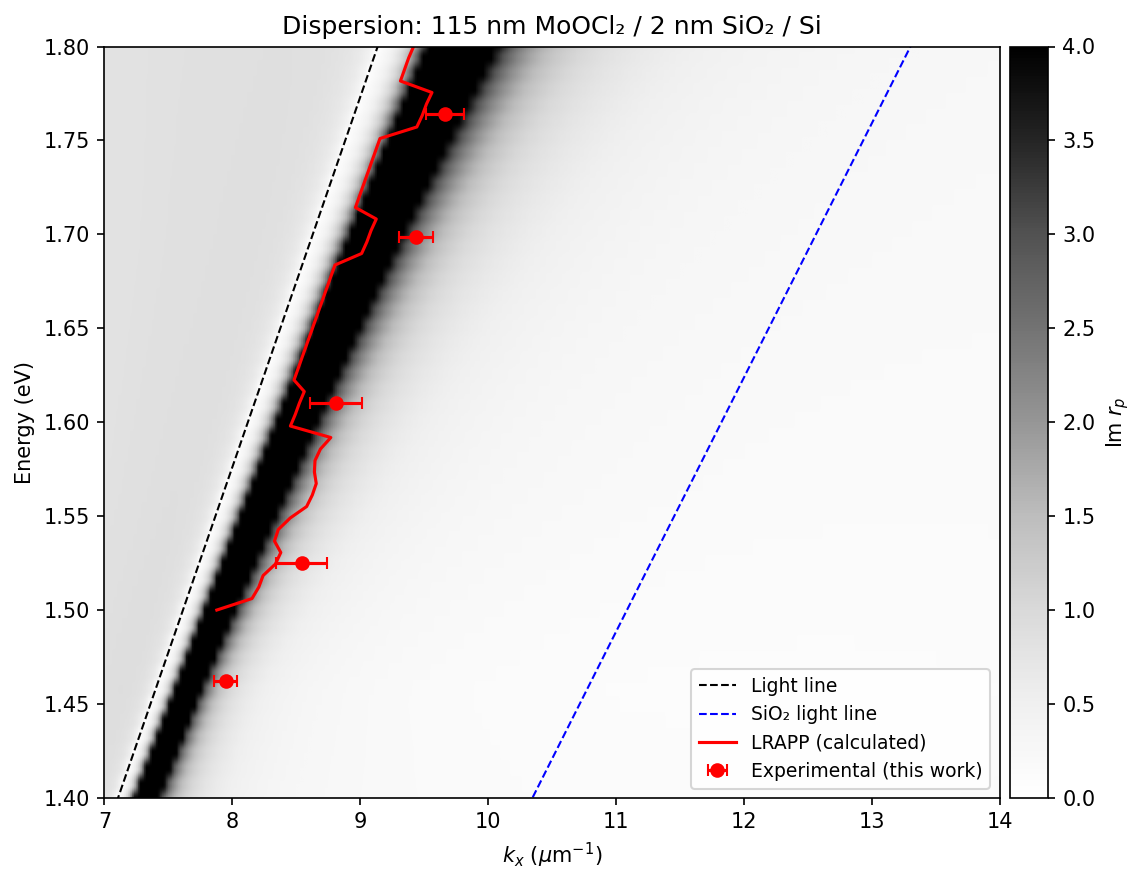

In [10]:
# ---------------------------------------------------------------------------
# Plot dispersion (Figure 3A)
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

im = ax.imshow(rp_map, cmap=cm.Greys, aspect='auto',
               extent=[k_disp[0], k_disp[-1], E0[0], E0[-1]],
               vmin=0, vmax=4, origin='lower')
plt.colorbar(im, ax=ax, pad=0.01, label=r'Im $r_p$')

# Light lines
ax.plot(E0/C_LIGHT, E0, 'k--', lw=1, label='Light line')
ax.plot(np.sqrt(2.12)*E0/C_LIGHT, E0, 'b--', lw=1, label='SiO₂ light line')

# Experimental data
ax.errorbar(exp_kx.real, exp_energies, xerr=exp_errors_re, 
            fmt='o', color='red', ecolor='red', capsize=3,
            label='Experimental (this work)')

# Calculated LRAPP dispersion
ax.plot(k_lrapp, E_disp, 'r-', lw=1.5, label='LRAPP (calculated)')

ax.set_xlim([7, k_disp[-1]])
ax.set_ylim([1.4, 1.8])
ax.set_xlabel(r"$k_x$ ($\mu$m$^{-1}$)")
ax.set_ylabel("Energy (eV)")
ax.set_title(f"Dispersion: {1000*D_MOOCL2:.0f} nm MoOCl₂ / {1000*D_SIO2:.0f} nm SiO₂ / Si")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("r_p_4layer.eps", format='eps', bbox_inches='tight', dpi=500)
plt.show()


## 7. Field Distributions for LRAPP and SRAPP <a id="7-field-distributions"></a>

Electric field (E_z) and Poynting vector distributions at 770 nm for both the upper (LRAPP) and lower (SRAPP) modes. These correspond to **Figures 3B–E** and **Figure S5** (charge density) in the manuscript.


In [11]:
def plot_field_distributions(omega, d1, d2, k_min_ratio, k_max_ratio, 
                             k_im_max, mode_label, z_range=(-0.2, 0.315)):
    """
    Solve for k_x and plot E_z, Poynting vector, and charge density.
    
    Parameters
    ----------
    omega : float
        Energy (eV).
    d1, d2 : float
        Layer thicknesses (μm).
    k_min_ratio, k_max_ratio : float
        Search bounds for k_x/k₀.
    k_im_max : float
        Max Im(k_x) search bound.
    mode_label : str
        'LRAPP' or 'SRAPP' for titles.
    z_range : tuple
        (z_min, z_max) for the spatial grid (μm).
    """
    ind = get_nearest_index(E0, omega)
    eps1 = 1.0
    eps_xy = melchioni_x[ind]
    eps_z_val = z_dft[ind]
    eps3 = diel_sio2[ind]
    eps4 = diel_si[ind]
    
    # Solve dispersion
    kx = solve_dispersion_4layer(omega, d1, d2, eps1, eps_xy, eps_z_val,
                                  eps3, eps4, k_min_ratio, k_max_ratio,
                                  k_im_max=k_im_max)
    if kx.real < 0 or kx.imag < 0:
        kx = -kx
    
    k0 = omega / C_LIGHT
    print(f"\n{mode_label} at {omega:.3f} eV ({1240/omega:.0f} nm):")
    print(f"  k_x = {kx:.4f} μm⁻¹")
    print(f"  k_x/k₀ = {(kx*C_LIGHT/omega).real:.4f}")
    print(f"  Propagation length = {np.abs(1/kx.imag):.1f} μm")
    
    # Compute fields
    z = np.linspace(z_range[0], z_range[1], 150)
    x = np.linspace(0, 1.5, 150)
    
    Ex, Ez, Hy, Sx, Sz, rho = calculate_fields_4layer(
        omega, kx, d1, d2, eps1, eps_xy, eps_z_val, eps3, eps4, x, z)
    
    # Coarse grid for vector arrows
    x2 = np.linspace(x[0], x[-1], 25)
    z2 = np.linspace(z_range[0], z_range[1], 25)
    Ex2, Ez2, _, Sx2, Sz2, _ = calculate_fields_4layer(
        omega, kx, d1, d2, eps1, eps_xy, eps_z_val, eps3, eps4, x2, z2)
    X, Z = np.meshgrid(x2, z2)
    
    # --- Electric field plot ---
    fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
    im = ax.imshow(Ez.real, cmap=cm.bwr, aspect='auto',
                   extent=[x[0], x[-1], z[0], z[-1]], 
                   vmin=-2, vmax=2, origin='lower')
    ax.quiver(X, Z, Ex2.real, -Ez2.real, units='xy', pivot='mid', 
              width=0.003, scale=70)
    for boundary in [0, d1, d1+d2]:
        ax.axhline(y=boundary, ls='--', color='black', lw=0.8)
    ax.set_xlabel("x (μm)")
    ax.set_ylabel("z (μm)")
    ax.set_title(f"{mode_label}: Re(E_z)")
    plt.colorbar(im, ax=ax, pad=0.01, label=r'Re $E_z$')
    plt.tight_layout()
    plt.savefig(f"{mode_label.lower()}_Ez.eps", bbox_inches='tight', dpi=500)
    plt.show()
    
    # --- Poynting vector plot ---
    fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
    s_mag = np.sqrt(Sx**2 + Sz**2)
    im = ax.imshow(s_mag, cmap=cm.Greens, aspect='auto',
                   extent=[x[0], x[-1], z[0], z[-1]], origin='lower')
    ax.quiver(X, Z, Sx2, -Sz2, units='xy', pivot='mid', scale=30)
    for boundary in [0, d1, d1+d2]:
        ax.axhline(y=boundary, ls='--', color='black', lw=0.8)
    ax.set_xlabel("x (μm)")
    ax.set_ylabel("z (μm)")
    ax.set_title(f"{mode_label}: |S|")
    plt.colorbar(im, ax=ax, pad=0.01, label='|S|')
    plt.tight_layout()
    plt.savefig(f"{mode_label.lower()}_S.eps", bbox_inches='tight', dpi=500)
    plt.show()
    
    # --- Charge density plot ---
    fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
    im = ax.imshow(rho, cmap=cm.bwr, aspect='auto',
                   extent=[x[0], x[-1], z[0], z[-1]], origin='lower')
    ax.quiver(X, Z, Ex2.real, -Ez2.real, units='xy', pivot='mid',
              width=0.003, scale=70)
    for boundary in [0, d1, d1+d2]:
        ax.axhline(y=boundary, ls='--', color='black', lw=0.8)
    ax.set_xlabel("x (μm)")
    ax.set_ylabel("z (μm)")
    ax.set_title(f"{mode_label}: Charge density ρ = ε₀∇·E")
    plt.colorbar(im, ax=ax, pad=0.01, label='ρ')
    plt.tight_layout()
    plt.savefig(f"{mode_label.lower()}_rho.eps", bbox_inches='tight', dpi=500)
    plt.show()
    
    return kx



LRAPP at 1.610 eV (770 nm):
  k_x = 8.5260+0.1006j μm⁻¹
  k_x/k₀ = 1.0430
  Propagation length = 9.9 μm


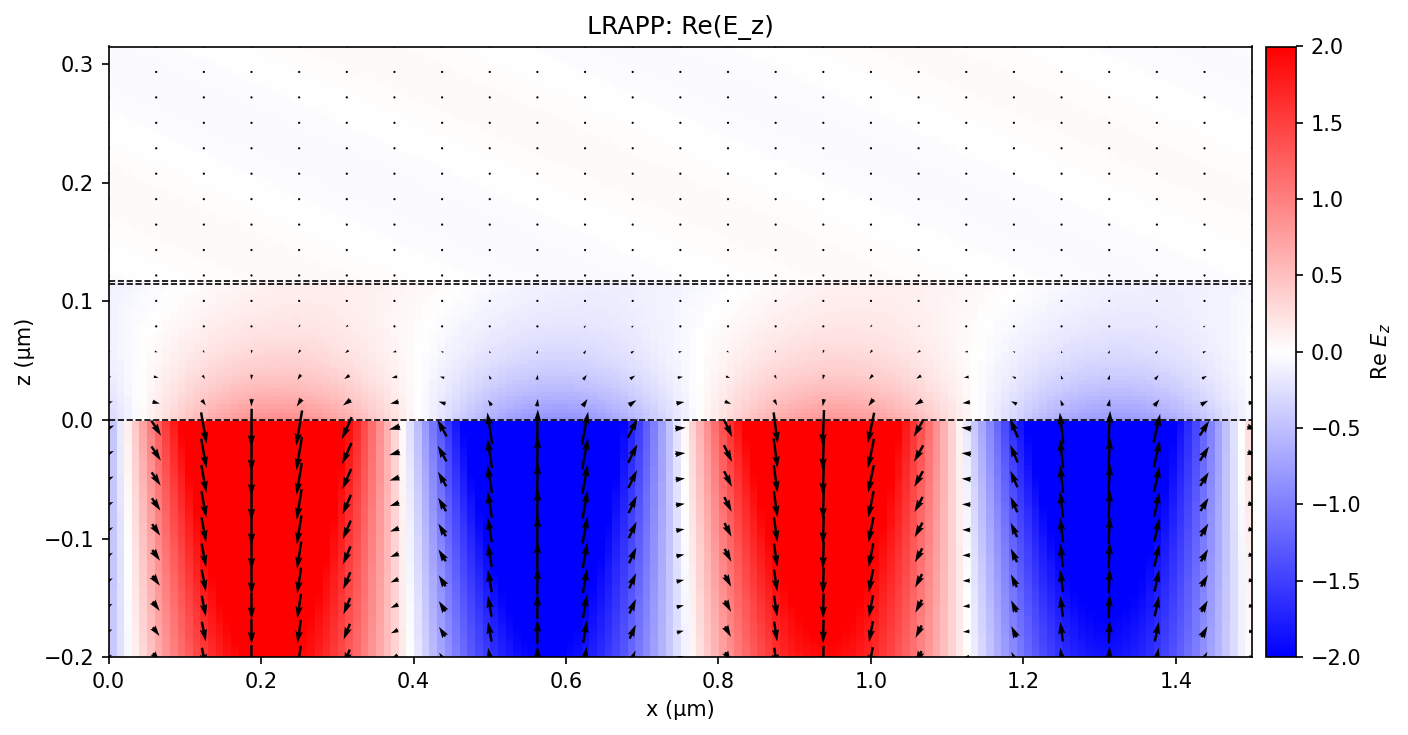

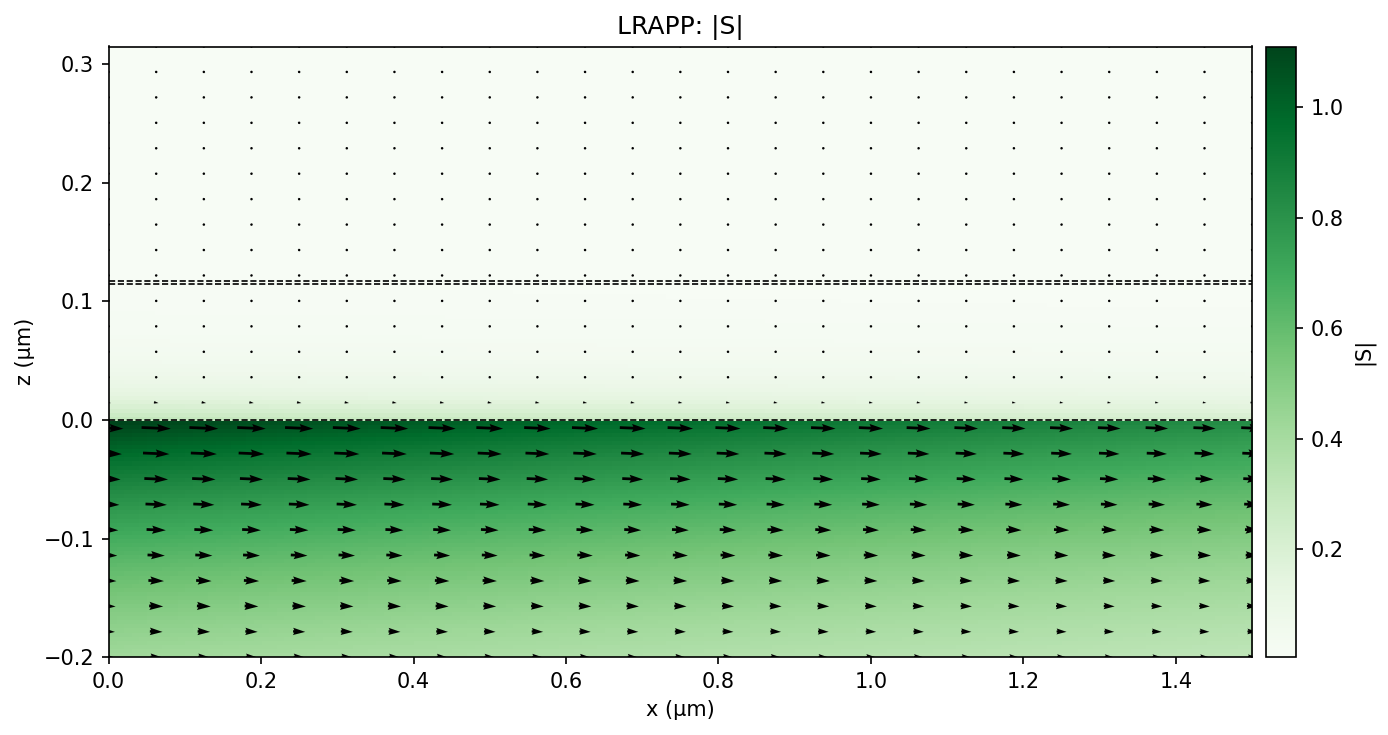

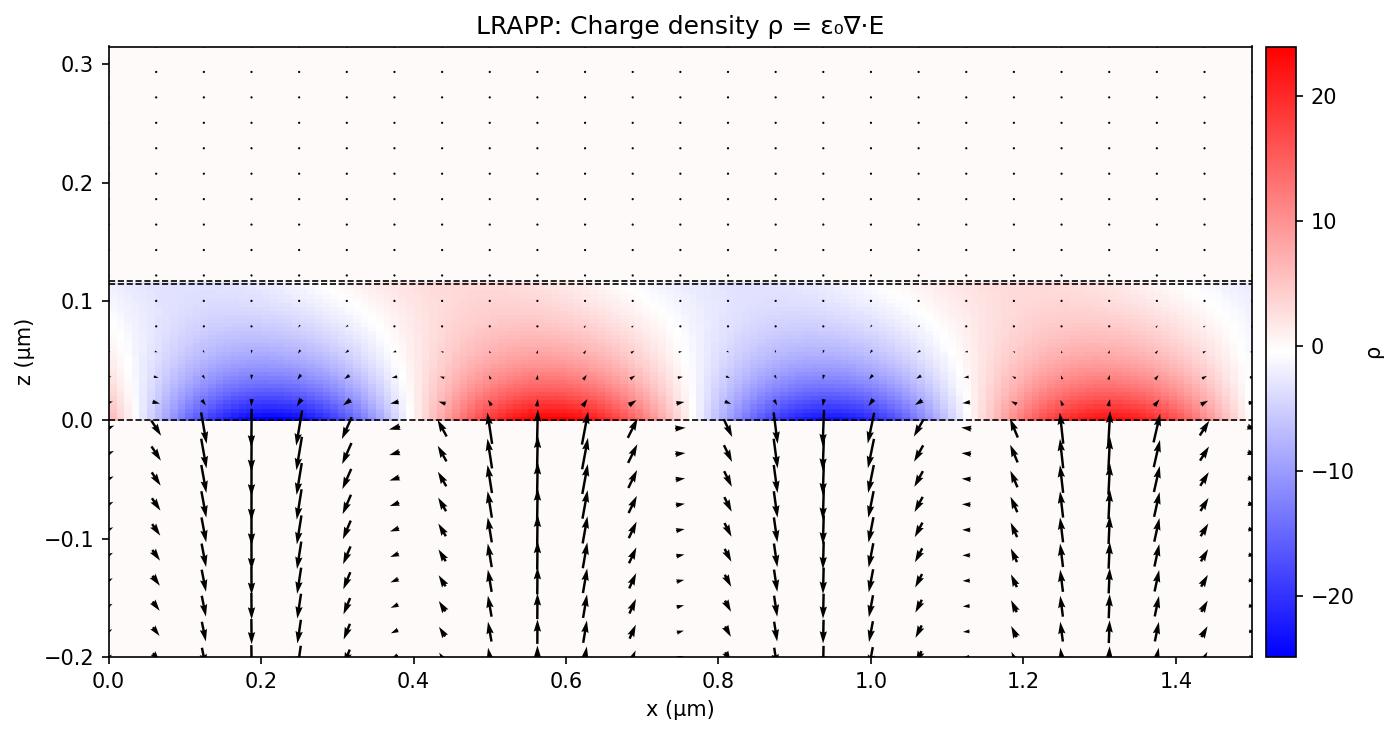

In [12]:
# LRAPP (upper mode): k_x/k₀ ≈ 1.0–1.2
eV_770 = 1240.0 / 770.0
kx_lrapp = plot_field_distributions(eV_770, D_MOOCL2, D_SIO2, 
                                     k_min_ratio=1.0, k_max_ratio=1.2,
                                     k_im_max=0.5, mode_label="LRAPP")



SRAPP at 1.610 eV (770 nm):
  k_x = 19.6869+0.0766j μm⁻¹
  k_x/k₀ = 2.4083
  Propagation length = 13.1 μm


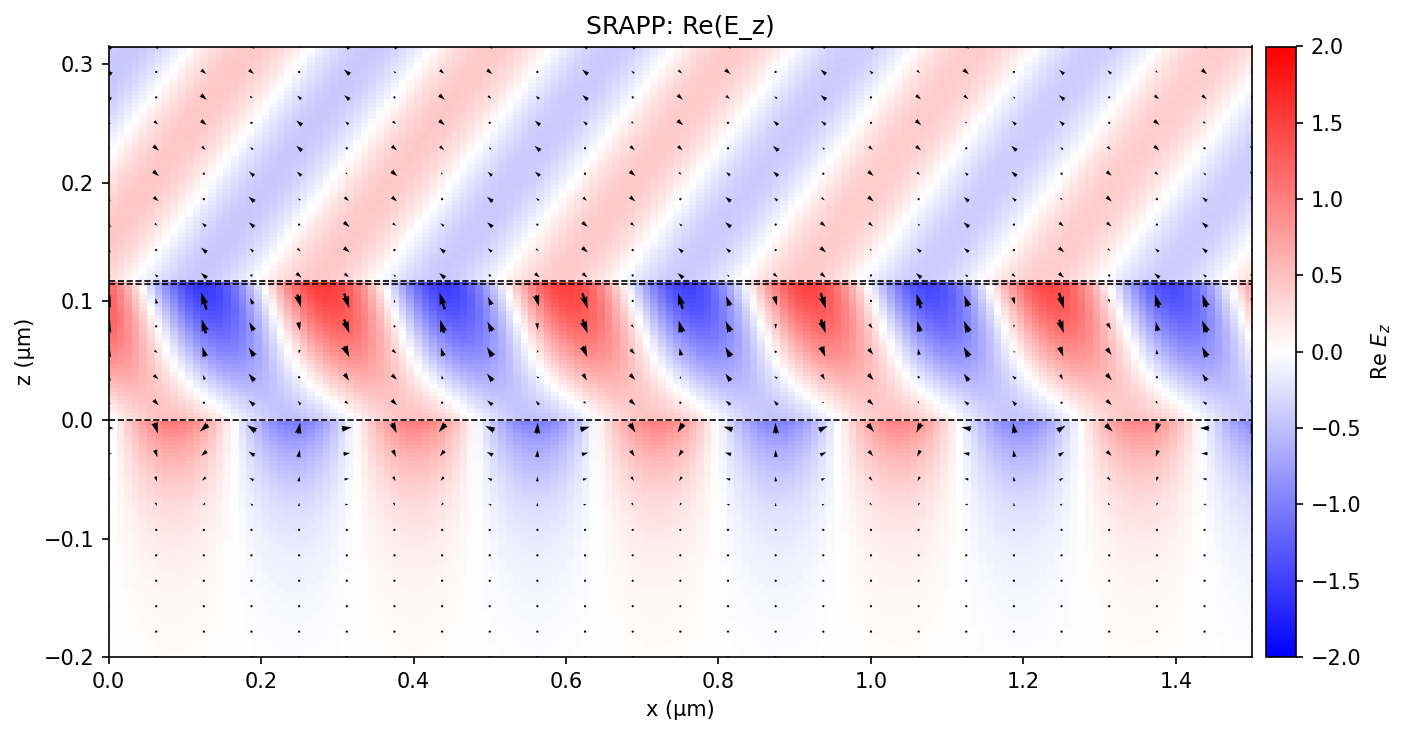

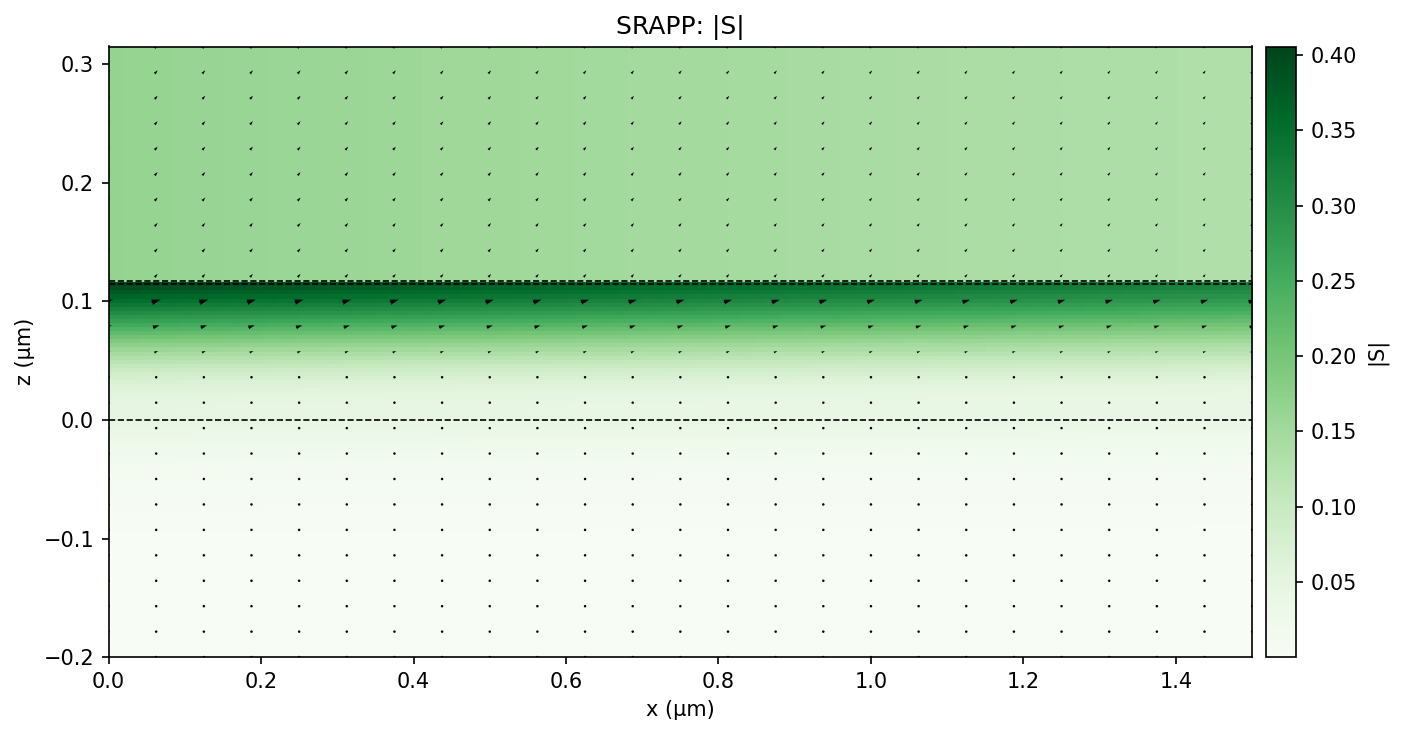

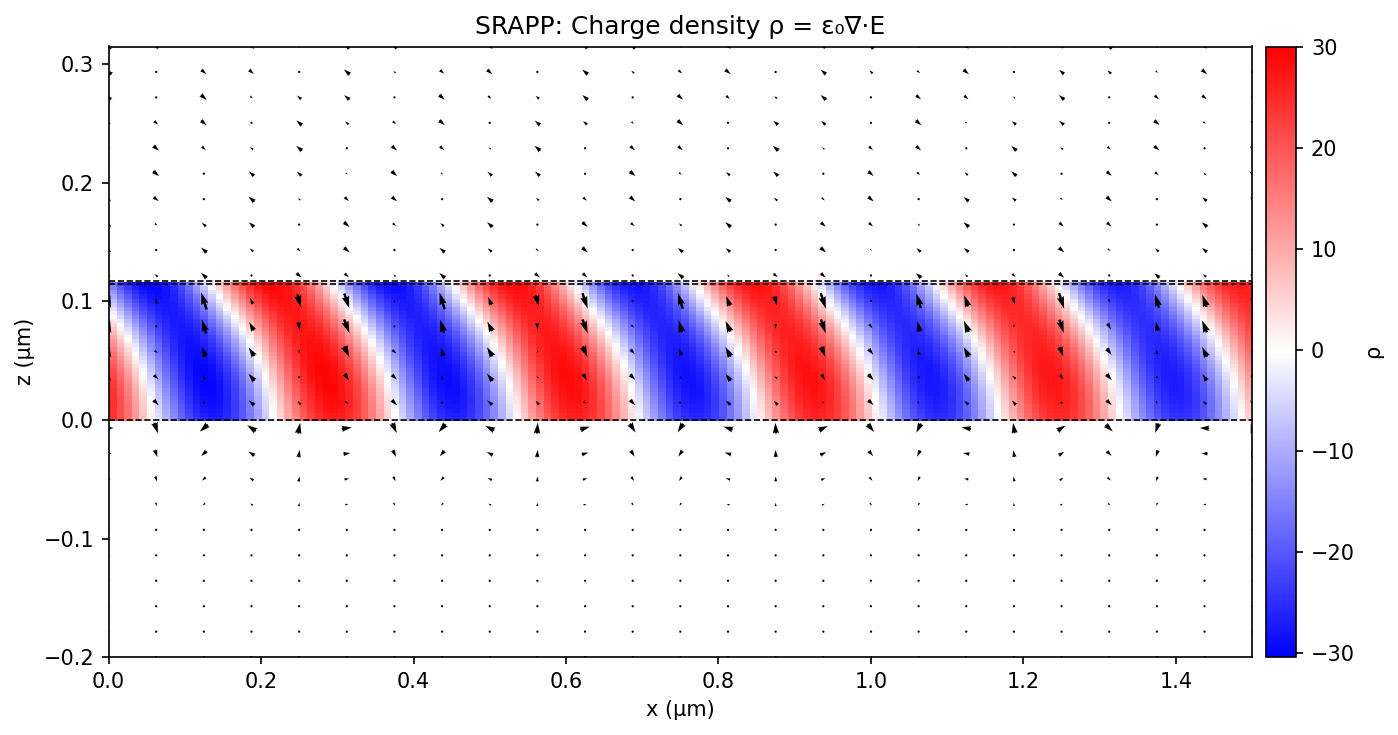

In [13]:
# SRAPP (lower mode): k_x/k₀ ≈ 1.5–3.0
kx_srapp = plot_field_distributions(eV_770, D_MOOCL2, D_SIO2,
                                     k_min_ratio=1.5, k_max_ratio=3.0,
                                     k_im_max=3.0, mode_label="SRAPP")


## 8. Group and Phase Velocity Comparison <a id="8-velocity-comparison"></a>

Compare theoretical group and phase velocities from the calculated dispersion with experimental values from TR-PEEM measurements (**Figure S9** of the Supplementary Information).


In [14]:
# ---------------------------------------------------------------------------
# Compute group and phase velocities from LRAPP dispersion
# ---------------------------------------------------------------------------

# Semi-infinite dispersion for comparison
def anisotropic_semi_infinite(omega, eps1, eps_xy, eps_z):
    """Semi-infinite anisotropic plasmon dispersion k_x(ω)."""
    return (omega/C_LIGHT) * np.emath.sqrt(eps1 * eps_z) * np.emath.sqrt(
        (eps1 - eps_xy) / (eps1**2 - eps_xy * eps_z))

k_semi_inf = anisotropic_semi_infinite(E0, ones, melchioni_x, z_dft)
vg_theory = np.gradient(E0, k_semi_inf.real)  # dE/dk

# Experimental values from TR-PEEM
vp_exp = 0.98  # ± 0.01 c
vg_exp = 0.68  # ± 0.09 c (updated: 0.69 in some places)
energy_exp = 1.6  # eV

# Theoretical values at 1.6 eV
ind_16 = get_nearest_index(E0, 1.6)
k_theory = k_semi_inf[ind_16].real
vg_th = vg_theory[ind_16]
vp_th = E0[ind_16] / (k_theory * C_LIGHT)  # ω/(k·c) in units of c

print(f"At 1.6 eV:")
print(f"  Theoretical: v_p = {vp_th:.2f} c, v_g = {vg_th/C_LIGHT:.2f} c")
print(f"  Experimental: v_p = {vp_exp} ± 0.01 c, v_g = {vg_exp} ± 0.09 c")


At 1.6 eV:
  Theoretical: v_p = 0.96 c, v_g = 0.85 c
  Experimental: v_p = 0.98 ± 0.01 c, v_g = 0.68 ± 0.09 c


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


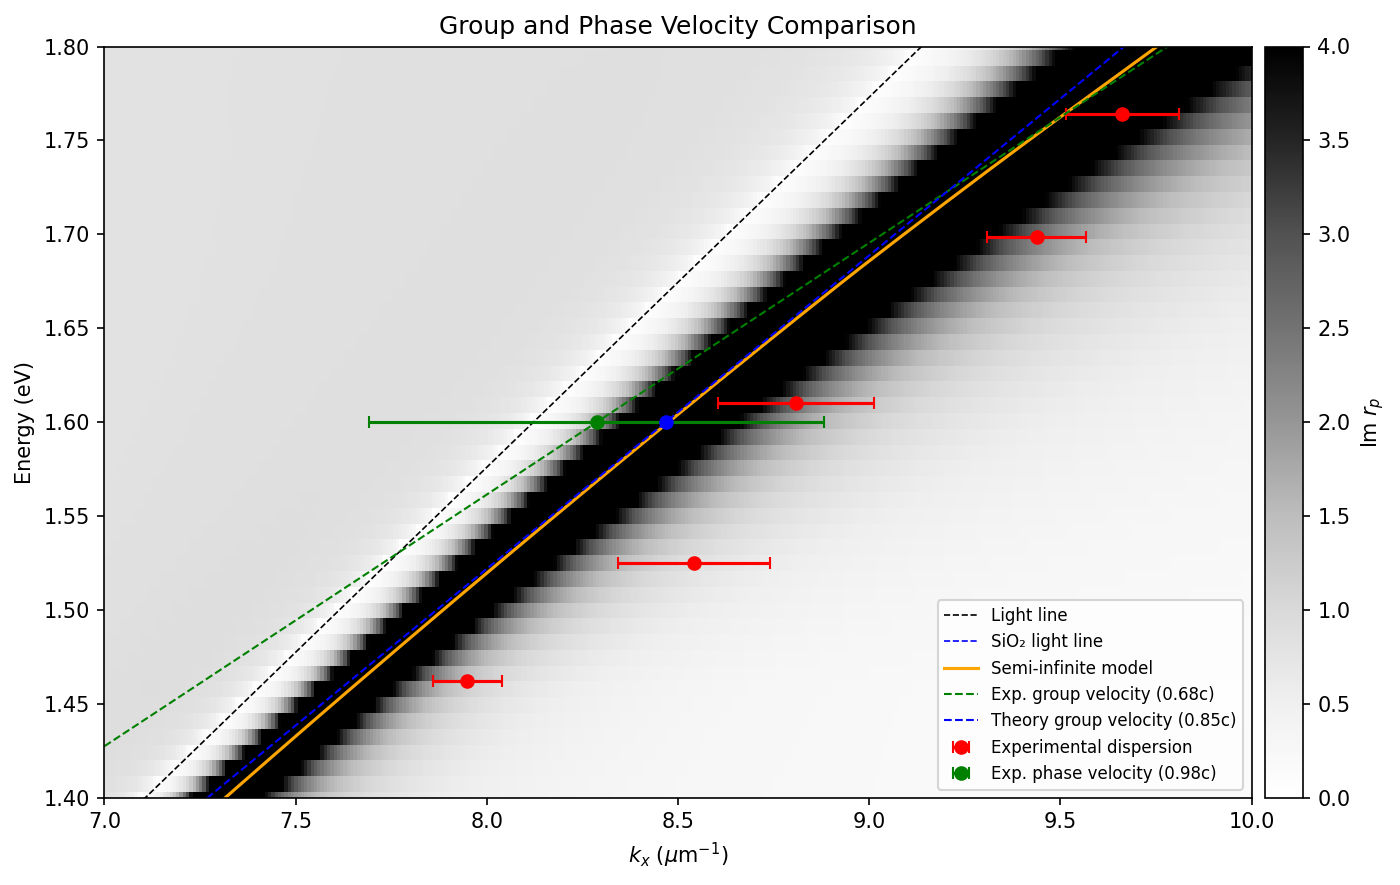

In [15]:
# ---------------------------------------------------------------------------
# Plot group/phase velocity comparison (Figure S9)
# ---------------------------------------------------------------------------
k_plot = np.linspace(7, 10, 350)

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

# Im(r_p) background
rp_fine = reflection_4layer(E0, k_plot, D_MOOCL2, D_SIO2, 
                            ones, melchioni_x, z_dft, diel_sio2, diel_si)
im = ax.imshow(rp_fine, cmap=cm.Greys, aspect='auto',
               extent=[k_plot[0], k_plot[-1], E0[0], E0[-1]],
               vmin=0, vmax=4, origin='lower')

# Reference lines
ax.plot(E0/C_LIGHT, E0, 'k--', lw=0.8, label='Light line')
ax.plot(np.sqrt(2.12)*E0/C_LIGHT, E0, 'b--', lw=0.8, label='SiO₂ light line')

# Semi-infinite model
ax.plot(k_semi_inf.real, E0, color='orange', lw=1.5, label='Semi-infinite model')

# Experimental dispersion points
ax.errorbar(exp_kx.real, exp_energies, xerr=exp_errors_re,
            fmt='o', color='red', ecolor='red', capsize=3, 
            label='Experimental dispersion')

# Phase velocity point and tangent
k_phase_exp = 1.6 / (vp_exp * C_LIGHT)
ph_err = 0.5 * 1.6 * np.abs(1/0.91 - 1/1.05) / C_LIGHT
ax.errorbar(k_phase_exp, 1.6, xerr=ph_err, fmt='o', color='green',
            ecolor='green', capsize=3, label=f'Exp. phase velocity ({vp_exp}c)')

# Group velocity tangent lines
ax.plot(k_plot, vg_exp*C_LIGHT*k_plot + 1.6 - vg_exp*C_LIGHT*k_phase_exp,
        'g--', lw=1, label=f'Exp. group velocity ({vg_exp}c)')
ax.plot(k_plot, vg_th*k_plot + 1.6 - vg_th*k_theory,
        'b--', lw=1, label=f'Theory group velocity ({vg_th/C_LIGHT:.2f}c)')
ax.plot(k_theory, 1.6, 'o', color='blue')

ax.set_xlim([7, k_plot[-1]])
ax.set_ylim([1.4, 1.8])
ax.set_xlabel(r"$k_x$ ($\mu$m$^{-1}$)")
ax.set_ylabel("Energy (eV)")
ax.set_title("Group and Phase Velocity Comparison")
ax.legend(fontsize=8, loc='lower right')
plt.colorbar(im, ax=ax, pad=0.01, label=r'Im $r_p$')
plt.tight_layout()
plt.savefig("vg_vph_comparison.eps", format='eps', bbox_inches='tight', dpi=500)
plt.show()
